# Importing libraries

In [351]:
import pandas as pd
import numpy as np
from pathlib import Path
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import LearningCurveDisplay
from sklearn.model_selection import ValidationCurveDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay

In [ ]:
pd.set_option('display.max_columns', None)

# Importing dataset

In [4]:
df = pd.read_stata("Raw_data.dta")

In [5]:
df.head()

,hhid,state,nss_region,district,employed_annual,num_activities_income,hasincome_selfemp_agri,hasincome_wage_agri,hasincome_casual_agri,hh_type,hoh_religion,caste,has_land,land_type,land_area,has_house,type_house,material_wall,material_roof,material_floor,type_rationcard,has_pmgky,used_ration,cons_served_processed,cons_packaged_processed,is_hhmem_pmjay,is_benefit_healthscheme,fuel_other,fuel_firewood,fuel_elec,fuel_kerosenePDS,fuel_keroseneother,fuel_lpg,fuel_total,has_tv,has_radio,has_laptop,has_mobile,has_bicycle,has_bike,has_car,has_truck,has_animalcart,has_fridge,has_washingmachine,has_acORcooler,total_expenditure,hh_size,sector,multiplier,mpce,decile,share_lpg,lpg_class
0,31000301,28,283,12,1,2,98,98,98,2,1,3,1,1,0.01,1,2,6,7,6,0,2,2,1500.0,15.0,2,98,27.0,0.0,80.0,0.0,0.0,240.0,347.0,98,98,98,1,98,98,98,98,98,98,98,98,19675.64,1.0,2,96498,19675.64,10,69.0,primary
1,31000302,28,283,12,1,2,98,98,98,2,1,3,1,1,0.02,1,2,6,8,6,4,1,1,1450.0,70.0,1,98,23.0,0.0,452.0,0.0,0.0,640.0,1115.0,1,98,98,1,98,1,98,98,98,98,98,98,40297.61,5.0,2,96498,8059.52,8,57.0,primary
2,31000303,28,283,12,1,2,98,98,98,2,1,3,1,1,0.03,1,2,6,8,6,4,1,1,150.0,130.0,1,98,27.0,0.0,482.0,0.0,0.0,720.0,1229.0,1,98,98,1,98,1,98,98,98,98,98,98,38140.10,5.0,2,96498,7628.02,8,59.0,primary
3,31000304,28,283,12,1,1,98,98,98,1,1,3,1,1,0.03,1,1,6,7,6,4,1,1,150.0,25.0,1,98,28.0,0.0,342.0,0.0,0.0,400.0,770.0,1,98,98,1,98,98,98,98,98,1,98,98,13045.25,2.0,2,96498,6522.62,7,52.0,primary
4,31000305,28,283,12,2,98,98,98,98,9,1,3,1,1,0.03,1,1,6,8,6,4,1,1,0.0,0.0,1,98,17.0,0.0,328.0,0.0,0.0,320.0,665.0,1,98,98,1,98,98,98,98,98,1,98,98,6765.77,1.0,2,96498,6765.77,7,48.0,secondary


# Train test split

In [6]:
X = df.copy()
X = X.drop(labels = ['share_lpg', 'lpg_class'], axis = 1)           # Removing LPG related data used for classification
X = X.drop(labels = ['fuel_other', 'fuel_firewood', 'fuel_elec',    # Removing all cooking fuel related data
                     'fuel_kerosenePDS', 'fuel_keroseneother', 
                     'fuel_lpg', 'fuel_total'], 
                     axis = 1)
X = X.drop(labels = ['hhid', 'multiplier', 'nss_region', 'district'], axis = 1)               # Removing other unnecessary columns

y = df['lpg_class'].copy()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42, stratify=y, shuffle=True)

# Encodings

In [8]:
# Categorisation of columns based on encoding needs

## Ordinal columns
ord_cols = ['decile']

## Nominal columns
nom_cols = ['state', 'employed_annual', 'num_activities_income', 'hasincome_selfemp_agri', 'hasincome_wage_agri',
            'hasincome_casual_agri', 'hh_type', 'hoh_religion', 'caste', 'has_land', 'land_type', 'has_house',
            'type_house', 'material_wall', 'material_roof', 'material_floor', 'type_rationcard', 'has_pmgky',
            'used_ration', 'is_hhmem_pmjay', 'is_benefit_healthscheme','has_tv', 'has_radio', 'has_laptop', 
            'has_mobile', 'has_bicycle', 'has_bike', 'has_car', 'has_truck', 'has_animalcart', 'has_fridge', 
            'has_washingmachine', 'has_acORcooler', 'sector']

## Numeric columns
num_cols = ['land_area', 'cons_served_processed', 'cons_packaged_processed','total_expenditure','hh_size',
            'mpce']

In [9]:
# Setting up transformer
ct = ColumnTransformer([("ordinal_encoding", OrdinalEncoder(categories=[['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']]), ord_cols),
                       ("onehot_encoding", OneHotEncoder(sparse_output=False), nom_cols)],
                       remainder= 'passthrough',
                       verbose_feature_names_out=False)
ct.set_output(transform='pandas')

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinal_encoding',
                                 OrdinalEncoder(categories=[['1', '2', '3', '4',
                                                             '5', '6', '7', '8',
                                                             '9', '10']]),
                                 ['decile']),
                                ('onehot_encoding',
                                 OneHotEncoder(sparse_output=False),
                                 ['state', 'employed_annual',
                                  'num_activities_income',
                                  'hasincome_selfemp_agri',
                                  'hasincome_wage_agri',
                                  'hasincome_casual_agri', 'hh_type',
                                  'hoh_religion', 'caste', 'has_land',
                                  'land_type', 'has_house', 'type_house',
                                  'material_wall', 'material_roof',
                                  'material_floor', 'type_rationcard',
                                  'has_pmgky', 'used_ration', 'is_hhmem_pmjay',
                                  'is_benefit_healthscheme', 'has_tv',
                                  'has_radio', 'has_laptop', 'has_mobile',
                                  'has_bicycle', 'has_bike', 'has_car',
                                  'has_truck', 'has_animalcart', ...])],
                  verbose_feature_names_out=False)

# Estimator

In [152]:
# Setting up the estimator

## Using different weights for each class
class_weights = {'primary': 1, 'secondary': 1, 'exclusive': 3, 'noLPG': 4}

## Estimator
rf = RandomForestClassifier(random_state=42, verbose = True, class_weight = class_weights)

# Pipeline

In [ ]:
# Setting up the pipeline
pipe = Pipeline([('column_transformer', ct), ('random_forest', rf)], verbose = True)

In [ ]:
# Seeing sample encoded data from the column transformer
X_train_enc = pipe['column_transformer'].fit_transform(X_train)
X_train_enc.head()

,decile,state_01,state_02,state_03,state_04,state_05,state_06,state_07,state_08,state_09,state_10,state_11,state_12,state_13,state_14,state_15,state_16,state_17,state_18,state_19,state_20,state_21,state_22,state_23,state_24,state_25,state_27,state_28,state_29,state_30,state_31,state_32,state_33,state_34,state_35,state_36,state_37,employed_annual_1,employed_annual_2,num_activities_income_1,num_activities_income_2,num_activities_income_3,num_activities_income_98,hasincome_selfemp_agri_1,hasincome_selfemp_agri_2,hasincome_selfemp_agri_98,hasincome_wage_agri_3,hasincome_wage_agri_4,hasincome_wage_agri_98,hasincome_casual_agri_5,hasincome_casual_agri_6,hasincome_casual_agri_98,hh_type_1,hh_type_2,hh_type_3,hh_type_4,hh_type_5,hh_type_6,hh_type_9,hoh_religion_0,hoh_religion_1,hoh_religion_2,hoh_religion_3,hoh_religion_4,hoh_religion_5,hoh_religion_6,hoh_religion_7,hoh_religion_9,caste_0,caste_1,caste_2,caste_3,caste_9,has_land_1,has_land_2,land_type_1,land_type_2,land_type_3,land_type_98,has_house_1,has_house_2,type_house_1,type_house_2,type_house_3,type_house_98,material_wall_1,material_wall_2,material_wall_3,material_wall_4,material_wall_5,material_wall_6,material_wall_7,material_wall_8,material_wall_9,material_wall_98,material_roof_1,material_roof_2,material_roof_3,material_roof_4,material_roof_5,material_roof_6,material_roof_7,material_roof_8,material_roof_9,material_roof_98,material_floor_1,material_floor_2,material_floor_3,material_floor_4,material_floor_5,material_floor_6,material_floor_7,material_floor_8,material_floor_9,material_floor_98,type_rationcard_0,type_rationcard_1,type_rationcard_2,type_rationcard_3,type_rationcard_4,type_rationcard_5,type_rationcard_9,has_pmgky_1,has_pmgky_2,used_ration_1,used_ration_2,is_hhmem_pmjay_1,is_hhmem_pmjay_2,is_benefit_healthscheme_1,is_benefit_healthscheme_2,is_benefit_healthscheme_98,has_tv_1,has_tv_98,has_radio_1,has_radio_98,has_laptop_1,has_laptop_98,has_mobile_1,has_mobile_98,has_bicycle_1,has_bicycle_98,has_bike_1,has_bike_98,has_car_1,has_car_98,has_truck_1,has_truck_98,has_animalcart_1,has_animalcart_98,has_fridge_1,has_fridge_98,has_washingmachine_1,has_washingmachine_98,has_acORcooler_1,has_acORcooler_98,sector_1,sector_2,land_area,cons_served_processed,cons_packaged_processed,total_expenditure,hh_size,mpce
91254,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.01,350.0,45.0,13826.23,2.0,6913.12
66375,8.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.12,150.0,200.0,34358.61,4.0,8589.65
160822,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0

# Model

## Manual

In [ ]:
# Setting up sample weights for the observations
sample_weights = df.loc[X_train.index, 'multiplier']
params = {pipe.steps[1][0] + '__sample_weight': sample_weights}

# Fitting the pipeline on training data with default parameters
pipe.fit(X_train, y_train, **params)

[Pipeline]  (step 1 of 2) Processing column_transformer, total=   4.8s


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   12.5s


[Pipeline] ..... (step 2 of 2) Processing random_forest, total=  25.7s


c:\Users\Tarun\Downloads\trial env\envl15nov\Lib\site-packages\sklearn\compose\_column_transformer.py:1651: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal_encoding',
                                                  OrdinalEncoder(categories=[['1',
                                                                              '2',
                                                                              '3',
                                                                              '4',
                                                                              '5',
                                                                              '6',
                                                                              '7',
                                                                              '8',
                                                                              '9',
                                                                              '10']]),
                                                  ['decile']),
                                                 ('onehot_encoding',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['state', 'employed_annual',
                                                   'num_activities_income',
                                                   'hasincome_selfemp_agri',
                                                   'hasincome_wage_agri',...
                                                   'is_benefit_healthscheme',
                                                   'has_tv', 'has_radio',
                                                   'has_laptop', 'has_mobile',
                                                   'has_bicycle', 'has_bike',
                                                   'has_car', 'has_truck',
                                                   'has_animalcart', ...])],
                                   verbose_feature_names_out=False)),
                ('random_forest',
                 RandomForestClassifier(class_weight={'exclusive': 3,
                                                      'noLPG': 4, 'primary': 1,
                                                      'secondary': 1},
                                        min_samples_split=0.1, random_state=42,
                                        verbose=True))],
         verbose=True)

## With tuned hyperparameters

In [ ]:
# Grid of hyperparameters
param_grid = {'random_forest__n_estimators': [50,100,150,200,250,300,350,400,450,500],
              'random_forest__min_samples_split': [0.01,0.05,0.1,0.15,0.2],
              'random_forest__max_features': ['sqrt',0.5,'log2']}

# Setting up randomised search
hyp_rf = RandomizedSearchCV(estimator = pipe,
                            param_distributions = param_grid,
                            scoring = 'accuracy',
                            cv = 5,
                            random_state=42,
                            verbose = 4)

# Setting up sample weights for the observations
sample_weights = df.loc[X_train.index, 'multiplier']
params = {pipe.steps[1][0] + '__sample_weight': sample_weights}

# Fitting the model
params = {pipe.steps[1][0] + '__sample_weight': sample_weights}
hyp_rf = hyp_rf.fit(X_train, y_train, **params)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[Pipeline]  (step 1 of 2) Processing column_transformer, total=   5.7s


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.1min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:  4.7min


[Pipeline] ..... (step 2 of 2) Processing random_forest, total= 4.8min


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.5s


[CV 1/5] END random_forest__max_features=0.5, random_forest__min_samples_split=0.1, random_forest__n_estimators=200;, score=0.509 total time= 4.9min
[Pipeline]  (step 1 of 2) Processing column_transformer, total=   7.1s


...

[Pipeline] ..... (step 2 of 2) Processing random_forest, total= 1.4min


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s


[CV 5/5] END random_forest__max_features=0.5, random_forest__min_samples_split=0.15, random_forest__n_estimators=150;, score=0.476 total time= 1.5min
[Pipeline]  (step 1 of 2) Processing column_transformer, total=   4.2s


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.1min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:  4.3min


[Pipeline] ..... (step 2 of 2) Processing random_forest, total= 5.4min


In [172]:
# List of parameter combinations run
print(f'List of parameters run: {hyp_rf.cv_results_['params']}')

# Performance of each model
print(f'\nMean validation scores: {hyp_rf.cv_results_['mean_test_score'].round(3)}')

# Best Parameters
print(f'\nThe following parameters: {hyp_rf.best_params_} have the best average accuracy score on CV dataset({hyp_rf.best_score_})')

List of parameters run: [{'random_forest__n_estimators': 200, 'random_forest__min_samples_split': 0.1, 'random_forest__max_features': 0.5}, {'random_forest__n_estimators': 450, 'random_forest__min_samples_split': 0.05, 'random_forest__max_features': 'sqrt'}, {'random_forest__n_estimators': 450, 'random_forest__min_samples_split': 0.05, 'random_forest__max_features': 'log2'}, {'random_forest__n_estimators': 450, 'random_forest__min_samples_split': 0.1, 'random_forest__max_features': 0.5}, {'random_forest__n_estimators': 350, 'random_forest__min_samples_split': 0.1, 'random_forest__max_features': 0.5}, {'random_forest__n_estimators': 100, 'random_forest__min_samples_split': 0.15, 'random_forest__max_features': 'sqrt'}, {'random_forest__n_estimators': 250, 'random_forest__min_samples_split': 0.05, 'random_forest__max_features': 0.5}, {'random_forest__n_estimators': 100, 'random_forest__min_samples_split': 0.2, 'random_forest__max_features': 'log2'}, {'random_forest__n_estimators': 450, 'r

In [340]:
# Cross validation accuracy scores for the best model
cv_scores = []
for i in range(0,5): 
    cv_scores.append(hyp_rf.cv_results_['split' + str(i) + '_test_score'][hyp_rf.best_index_].round(2))
print(cv_scores)

[np.float64(0.54), np.float64(0.53), np.float64(0.53), np.float64(0.54), np.float64(0.54)]


## Final model (tuned)

In [160]:
hyp_rf

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('column_transformer',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ordinal_encoding',
                                                                               OrdinalEncoder(categories=[['1',
                                                                                                           '2',
                                                                                                           '3',
                                                                                                           '4',
                                                                                                           '5',
                                                                                                           '6',
                                                                                                           '7',
                                                                                                           '8',
                                                                                                           '9',
                                                                                                           '10']]),
                                                                               ['decile']),
                                                                              ('onehot_encoding',
                                                                               OneHotEncoder(sparse_output=False),
                                                                               ['state',
                                                                                'employed_annual',
                                                                                'num_activities_income',
                                                                                'hasincome_se...
                                                                                   'noLPG': 4,
                                                                                   'primary': 1,
                                                                                   'secondary': 1},
                                                                     min_samples_split=0.1,
                                                                     random_state=42,
                                                                     verbose=True))],
                                      verbose=True),
                   param_distributions={'random_forest__max_features': ['sqrt',
                                                                        0.5,
                                                                        'log2'],
                                        'random_forest__min_samples_split': [0.01,
                                                                             0.05,
                                                                             0.1,
                                                                             0.15,
                                                                             0.2],
                                        'random_forest__n_estimators': [50, 100,
                                                                        150,
                                                                        200,
                                                                        250,
                                                                        300,
                                                                        350,
                                                                        400,
                                                                        450,
                   

# Evaluation

## Precision, recall, accuracy and F1 scores for each class

In [ ]:
y_pred = hyp_rf.predict(X_test)
pd.DataFrame(classification_report(y_test,y_pred, sample_weight=df.loc[X_test.index, 'multiplier'], output_dict=True)).style.format('{:.2f}')

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
c:\Users\Tarun\Downloads\trial env\envl15nov\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tarun\Downloads\trial env\envl15nov\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tarun\Downloads\trial env\envl15nov\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predic

,exclusive,noLPG,primary,secondary,accuracy,macro avg,weighted avg
precision,0.00,0.46,0.66,0.63,0.54,0.44,0.59
recall,0.00,0.94,0.49,0.22,0.54,0.41,0.54
f1-score,0.00,0.61,0.56,0.33,0.54,0.38,0.50
support,1226109.00,2441238042.00,3457426196.00,2629012066.00,0.54,8528902413.00,8528902413.00


## ROC curve

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.6s


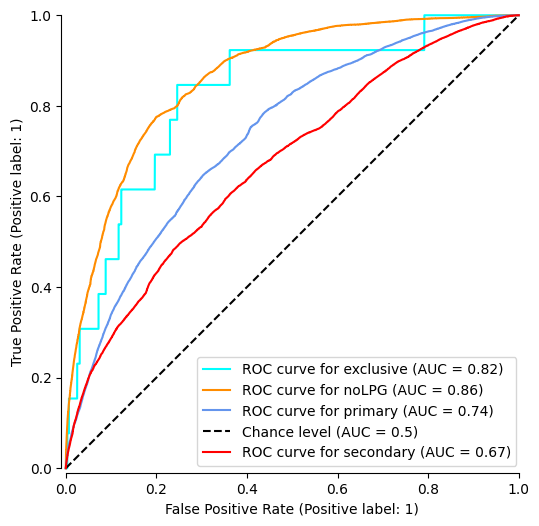

In [383]:
y_score = hyp_rf.predict_proba(X_test)

label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)

class_of_interest = 'noLPG'
class_id = np.flatnonzero(label_binarizer.classes_ == class_of_interest)
colors = cycle(["aqua", "darkorange", "cornflowerblue", "red"])
n_classes = len(np.unique(y_train))

fig, ax = plt.subplots(figsize=(6, 6))
for class_id, color in zip(range(n_classes), colors):
    params = {'c': color}
    RocCurveDisplay.from_predictions(
        y_onehot_test[:, class_id],
        y_score[:, class_id],
        name=f"ROC curve for {label_binarizer.classes_[class_id]}",
        **params,
        ax = ax,
        plot_chance_level=(class_id == 2),
        despine=True,
    )


# Feature importance

### Visualising first tree of RF

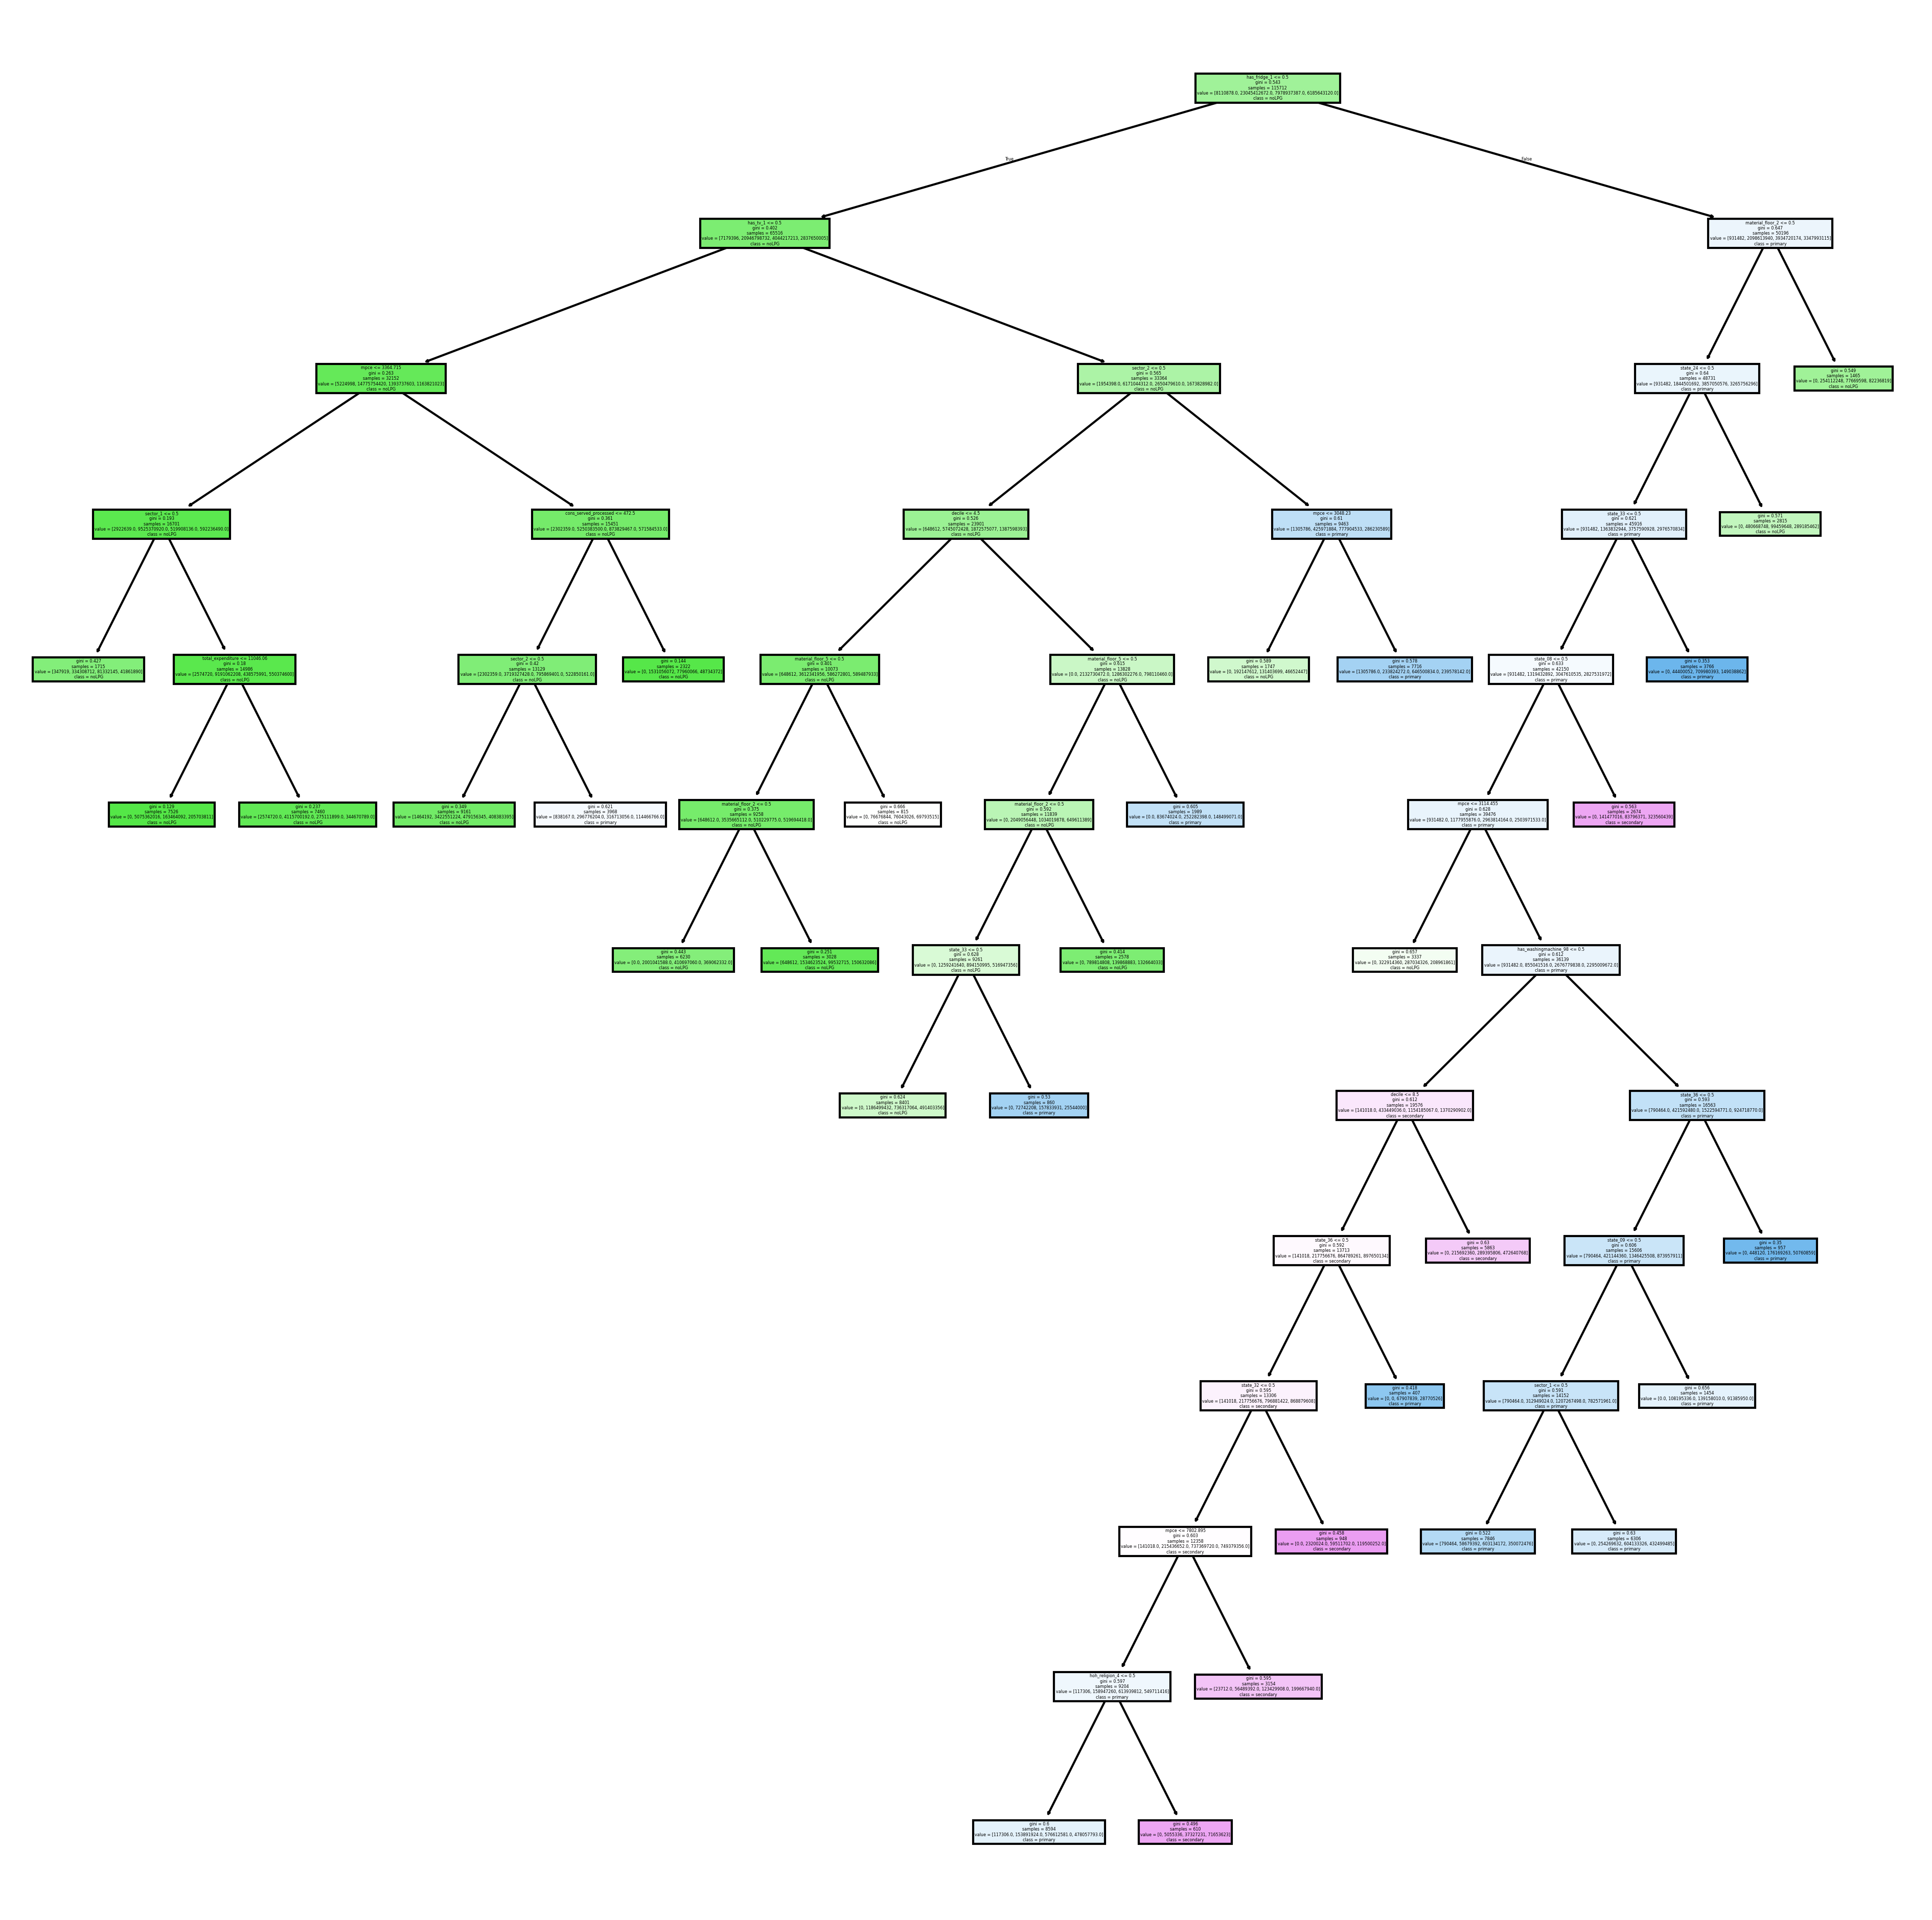

In [211]:
from sklearn import tree
plt.subplots(nrows = 1,ncols = 1,figsize = (16,16), dpi=300)
tree.plot_tree(hyp_rf.best_estimator_['random_forest'].estimators_[0],
               feature_names=X_train_enc.columns,
               filled = True,
               class_names = hyp_rf.classes_)
plt.show()

### Importance scores

In [218]:
# Feature importance table

## Extracting mean feature importances
importances = hyp_rf.best_estimator_['random_forest'].feature_importances_

## Extracting standard deviations of each feature's importance
std = np.std([tree.feature_importances_ for tree in hyp_rf.best_estimator_['random_forest'].estimators_], axis = 0)

## Creating dataframe
feature_names = X_train_enc.columns
forest_importances = pd.DataFrame({'mean': importances, 'std': std}, index = feature_names)
forest_importances = forest_importances.sort_values(by = 'mean', ascending = False)

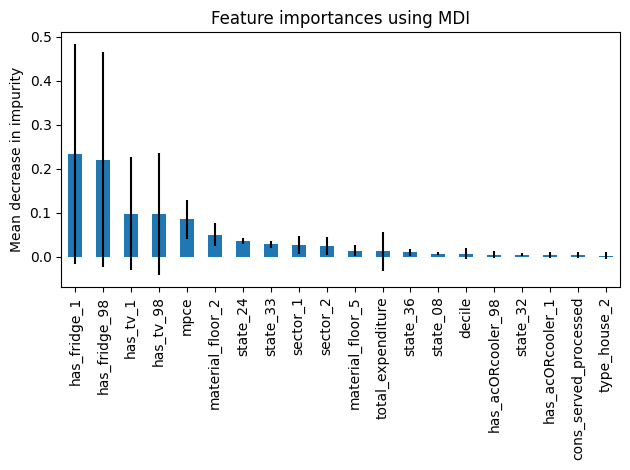

In [203]:
# Feature importance plot (top 20 features)
fig, ax = plt.subplots()
forest_importances.iloc[:20,0].plot.bar(yerr=forest_importances.iloc[:20,1], ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

# Learnings
1. Reduce max_features to introduce randomness and improve comp time. Keep it to default.
2. Use min_sample_split to reduce overfitting.
3. Use n_estimators at 250